## **Human Activity Recognition Using Machine Learning and Deep Learning**

**Importing Relevant Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

**Loading The Files**

In [2]:
train = pd.read_csv("/content/test.csv")
test = pd.read_csv("/content/train.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (2947, 563)
Test shape: (7352, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


**Check the activity classes**

In [3]:
print(train["Activity"].value_counts())

Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64


**Split features and target**

In [4]:
X_train = train.drop(columns=["Activity"])
y_train = train["Activity"]

X_test = test.drop(columns=["Activity"])
y_test = test["Activity"]

**Encode target labels**

In [5]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

print(encoder.classes_)

['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


**Scale the features**

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Baseline model — Logistic Regression:**

In [7]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train_encoded)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test_encoded, y_pred_lr))
print(classification_report(y_test_encoded, y_pred_lr, target_names=encoder.classes_))

Logistic Regression Accuracy: 0.9333514689880305
                    precision    recall  f1-score   support

            LAYING       0.99      0.99      0.99      1407
           SITTING       0.86      0.93      0.89      1286
          STANDING       0.93      0.86      0.90      1374
           WALKING       0.98      0.93      0.95      1226
WALKING_DOWNSTAIRS       0.93      0.96      0.95       986
  WALKING_UPSTAIRS       0.91      0.94      0.92      1073

          accuracy                           0.93      7352
         macro avg       0.93      0.93      0.93      7352
      weighted avg       0.94      0.93      0.93      7352



**Baseline model — Random Forest**

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train_encoded)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test_encoded, y_pred_rf))
print(classification_report(y_test_encoded, y_pred_rf, target_names=encoder.classes_))

Random Forest Accuracy: 0.9106365614798694
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      0.99      1407
           SITTING       0.82      0.92      0.87      1286
          STANDING       0.92      0.82      0.87      1374
           WALKING       0.99      0.88      0.93      1226
WALKING_DOWNSTAIRS       0.87      0.95      0.91       986
  WALKING_UPSTAIRS       0.87      0.90      0.89      1073

          accuracy                           0.91      7352
         macro avg       0.91      0.91      0.91      7352
      weighted avg       0.91      0.91      0.91      7352



**LSTM preparation**

In [9]:
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)

**Build LSTM model**

In [10]:
model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(6, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │       160,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,790 (635.90 KB)

 Trainable params: 162,790 (635.90 KB)

 Non-trainable params: 0 (0.00 B)

**Train LSTM**

In [11]:
history = model.fit(
    X_train_lstm,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_cat)
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.6909 - loss: 0.9551 - val_accuracy: 0.8191 - val_loss: 0.5707
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9074 - loss: 0.3697 - val_accuracy: 0.8838 - val_loss: 0.3537
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9511 - loss: 0.1867 - val_accuracy: 0.9053 - val_loss: 0.2728
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9735 - loss: 0.1024 - val_accuracy: 0.9100 - val_loss: 0.2671
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9756 - loss: 0.0877 - val_accuracy: 0.9127 - val_loss: 0.2691
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9827 - loss: 0.0611 - val_accuracy: 0.9162 - val_loss: 0.2665
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9857 - loss: 0.0500 - val_accuracy: 0.9071 - val_loss: 0.2951
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9817 - loss: 0.0546 - val_accuracy: 0.9161 - 

**Evaluate LSTM**

In [13]:
loss, accuracy = model.evaluate(X_test_lstm, y_test_cat)
print("LSTM Accuracy:", accuracy)

230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9215 - loss: 0.2768
LSTM Accuracy: 0.9215179681777954


**Confusion matrix for LSTM**

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


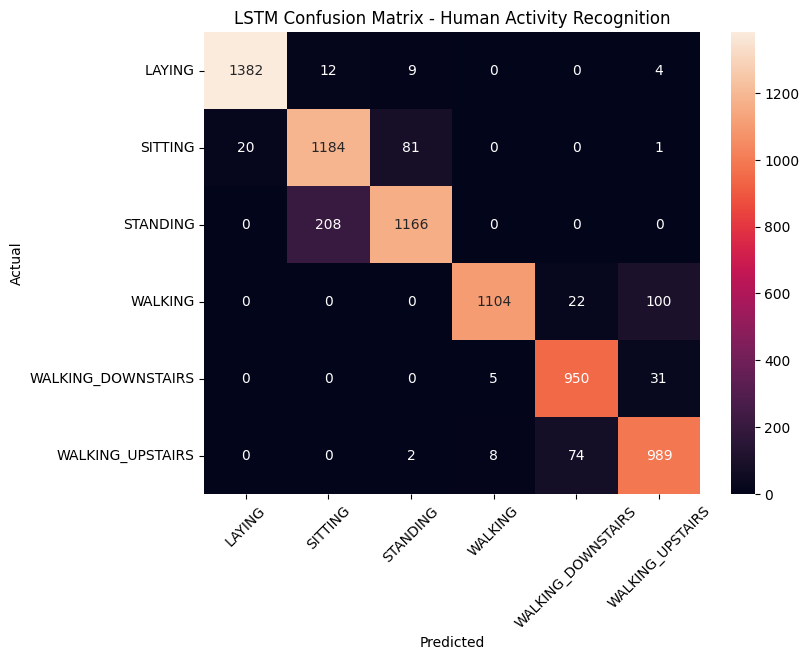

<Figure size 640x480 with 0 Axes>

In [15]:
y_pred_lstm_prob = model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

cm = confusion_matrix(y_test_encoded, y_pred_lstm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix - Human Activity Recognition")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()